In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
BLTP1_predictions = pd.read_csv("../data/BLTP1_c_13476C_T_Predictions.csv")
CFTR_predictions = pd.read_csv("../data/CFTR_G542X_Predictions.csv")

In [3]:
def plot_variant(df, variant_name, xlabel):
    model_order = ["Measured PSI", "SpliceAI", "Pangolin", "AlphaGenome"][::-1]
    ypos = {model: i for i, model in enumerate(model_order)}
    df["ypos"] = df["Model"].map(ypos)
    
    fig, ax = plt.subplots(figsize=(2.0, 0.9), dpi=600)
    
    # Scatter points
    sns.scatterplot(
        data=df,
        x="Score",
        y="ypos",
        hue="Type",
        s=45,
        zorder=0,
        alpha=1,
        palette={"Wildtype": "tab:grey", variant_name: "tab:red"}
    )

    # Draw change in score
    for model in model_order:
        sub = df[df["Model"] == model].sort_values("Type")
        x_values = sub["Score"].values
        y_values = sub["ypos"].values
            
        delta = x_values[1] - x_values[0]
        if round(delta, 2) == 0:
            delta = 0
        
        # Annotate above the line (midpoint)
        ax.text(
            x=(x_values[0] + x_values[1])/2,
            y=y_values[0] + 0.2,
            s=f"Δ = {delta:.1f}",
            ha="center",
            va="bottom",
            fontsize=7,
            color="black"
        )

        if abs(delta) > 5:
            if x_values[1] > x_values[0]:
                style = "-|>"
            else:
                style = "<|-"
            
            ax.annotate(
                "",
                xy=(x_values[0] - 0.005, y_values[0]),
                xytext=(x_values[1] + 0.003, y_values[1]),
                arrowprops=dict(arrowstyle=style, color="tab:grey", linestyle="solid", lw=0.75, alpha=1),
                zorder=4
            )
    
    # Tidy up
    ax.set_yticks(list(ypos.values()))
    ax.set_yticklabels(model_order)
    ax.set_ylim(-0.4, len(model_order)-0.6)
    ax.set_xlim(0, 105)
    ax.set_xlabel(r"$BLTP1$ Exon 79 Score")
    ax.set_ylabel("")
    sns.despine(trim=False)
    ax.legend(ncols=2, loc="lower center", bbox_to_anchor=(0.5, -1.2))

    return fig

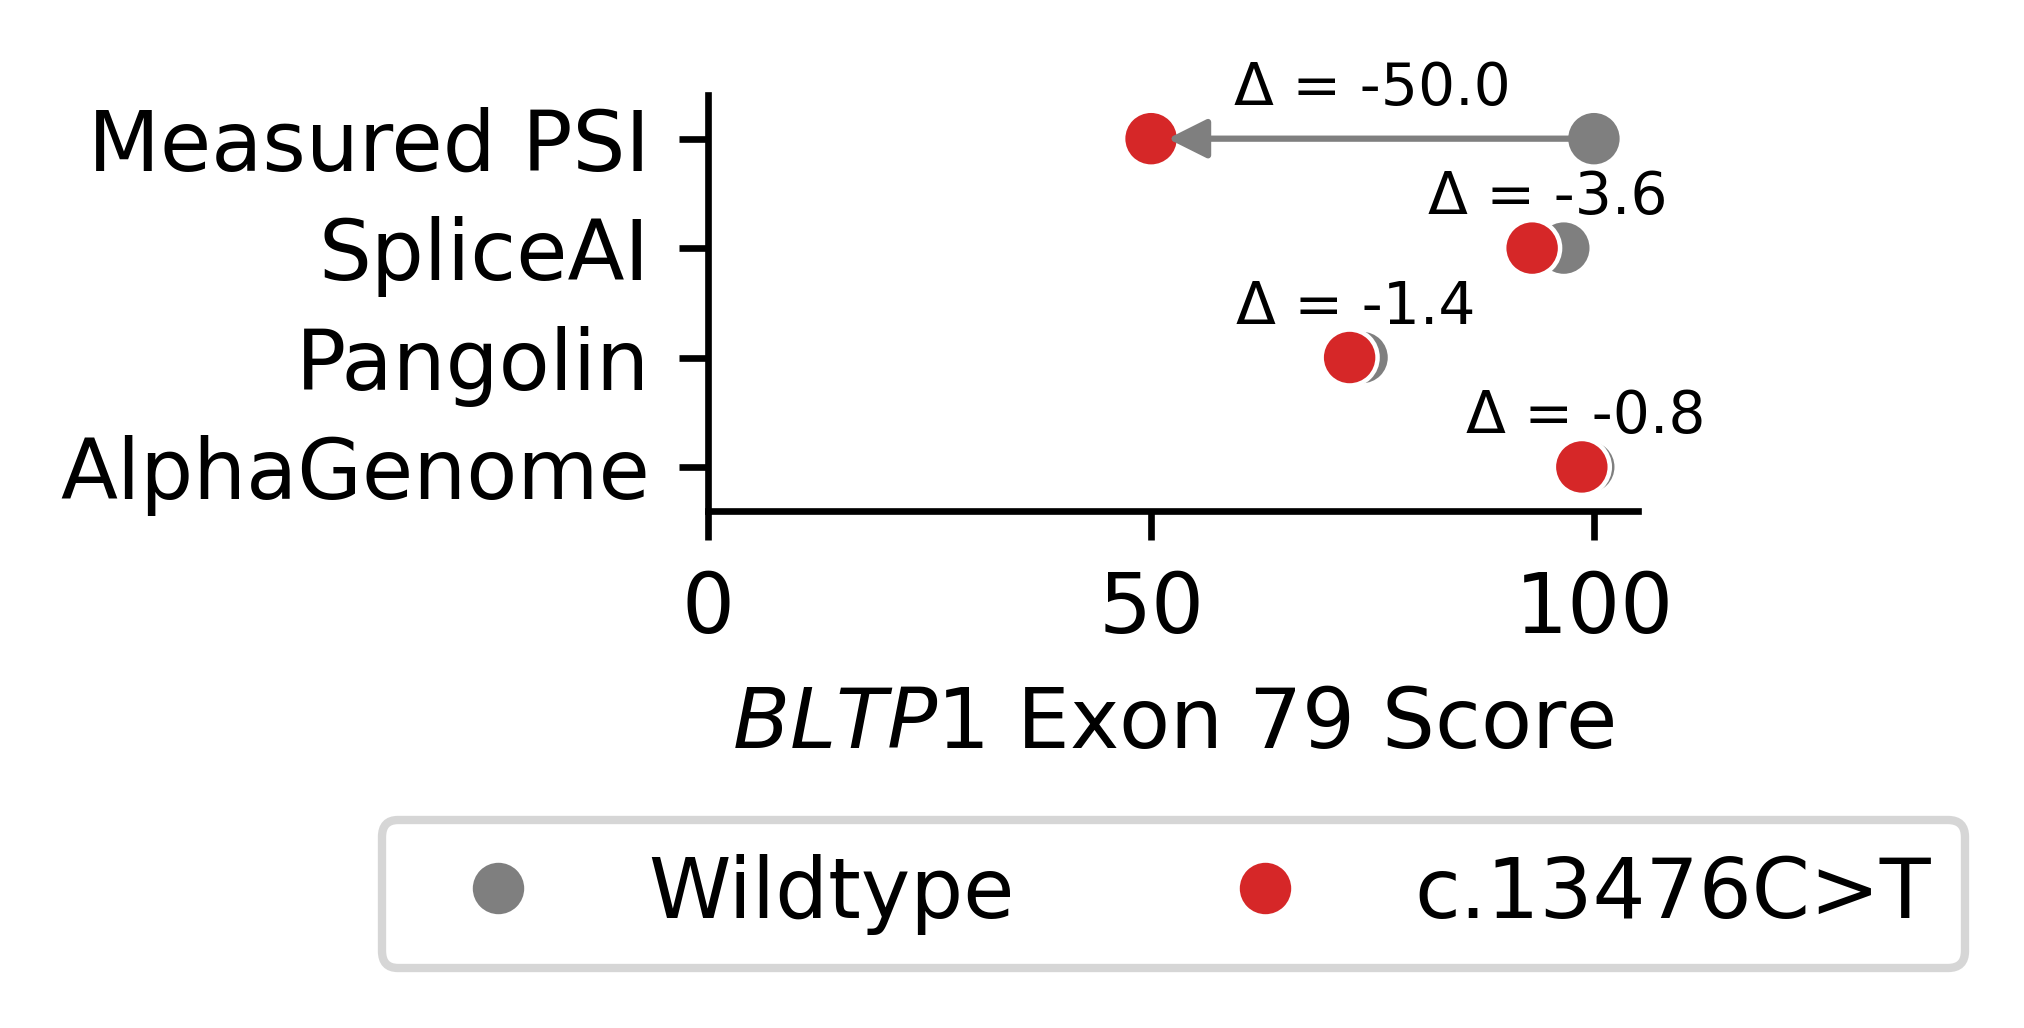

In [4]:
fig = plot_variant(BLTP1_predictions, "c.13476C>T", r"$BLTP1 Exon 79 Score")

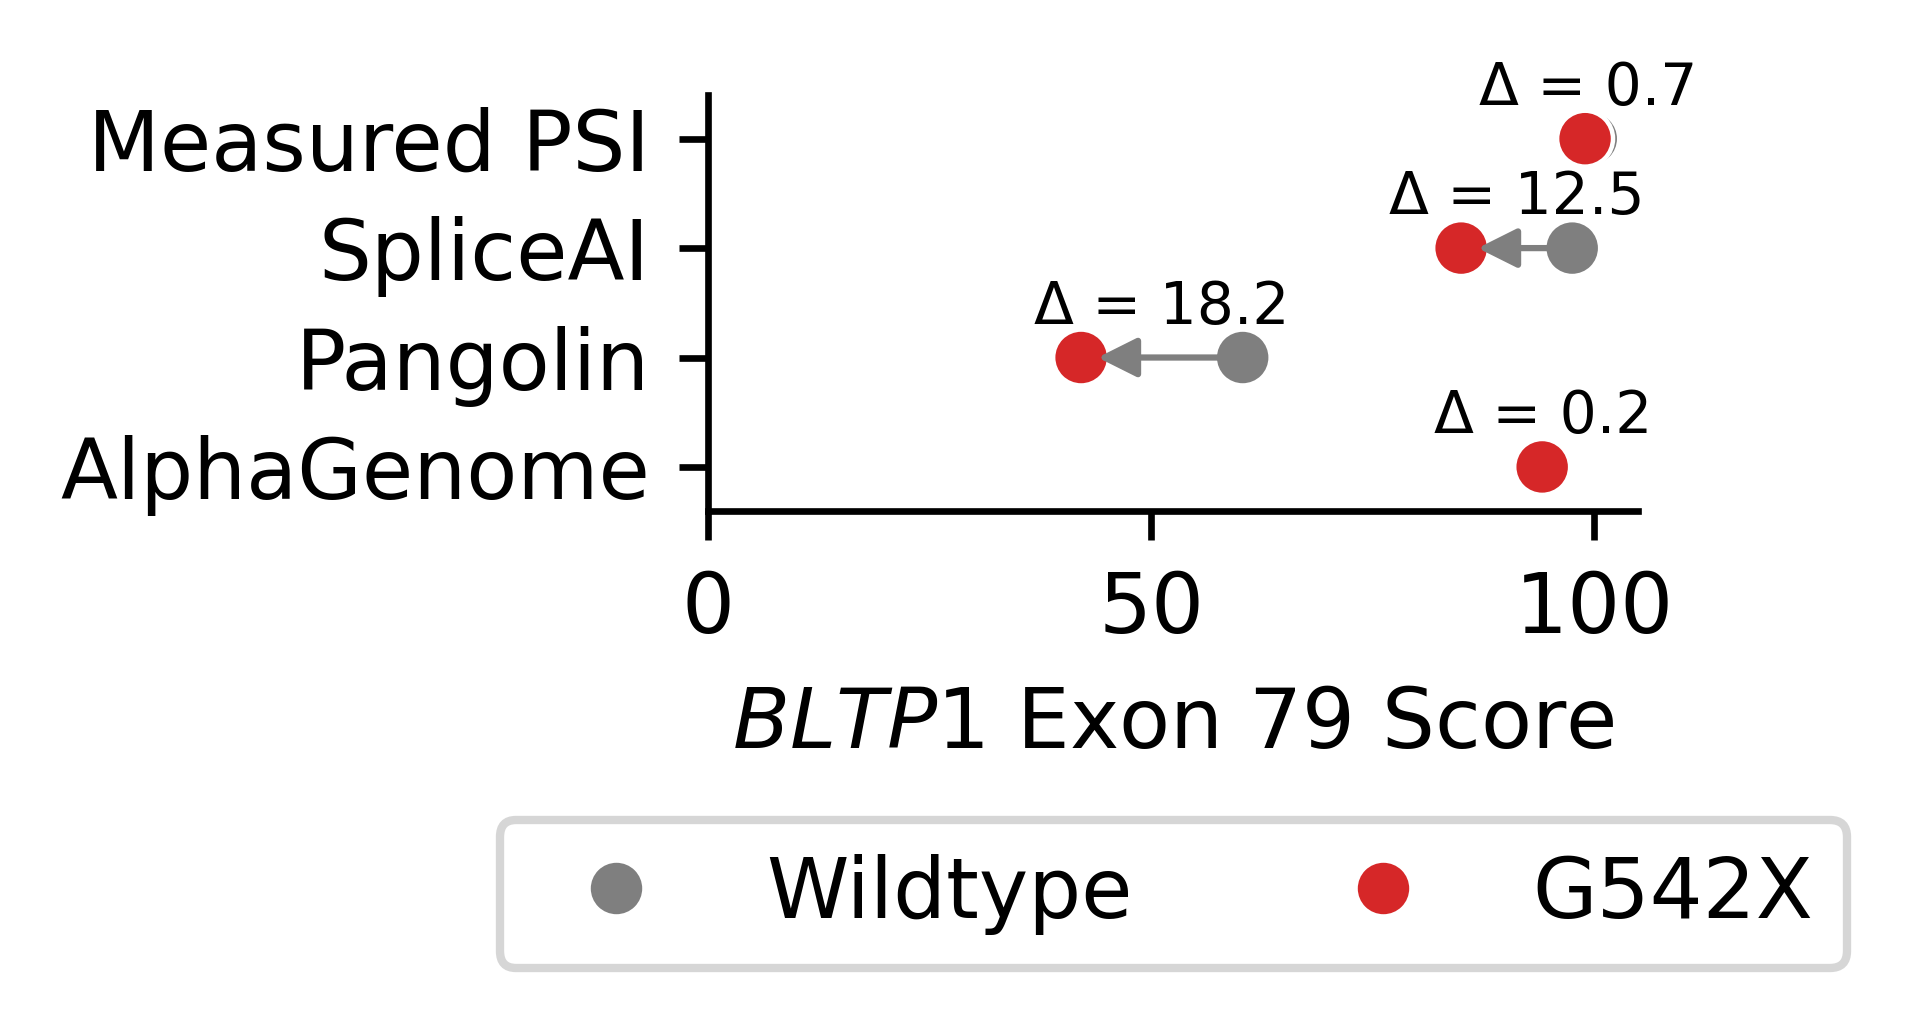

In [5]:
fig = plot_variant(CFTR_predictions, "G542X", r"$CFTR$ Exon 12 Score")